# Seasonal Distribution and Spreading

In [1]:
import cmocean.cm as cm
import copy
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pandas as pd
from matplotlib.colors import ListedColormap
from scipy.optimize import curve_fit
import matplotlib.gridspec as gridspec
mask = xr.open_dataset('/ocean/vvalenzuela/MOAD/grid2/mesh_mask202108_TDV.nc')

In [2]:
file_year1 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_1.nc'
file_year2 = '/home/vvalenzuela/MOAD/Ocean_Parcels/Results_Final_Versions/Version_4_final/Simulation_V4_year_2.nc'

In [3]:
vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'time', 'status']

In [4]:
def finder2(target_lat, target_lon,mask=mask):
# Load grid data (e.g., from a NetCDF file)
    lat = mask.nav_lat
    lon = mask.nav_lon
    #find closest grid
    distance = ((lat - target_lat)**2 + (lon - target_lon)**2)**0.5
    nearest_index = distance.argmin()
    return int(nearest_index // lon.shape[1]), int(nearest_index % lon.shape[1])

In [5]:
from scipy.spatial import cKDTree

def particles_amount_map_aged(
    lons, lats, depths, ages, depth_bins, mask,
    num_lon=200, num_lat=200, age_freq_days=3
):
    # Floor ages to the nearest frequency bin (e.g., 0, 3, 6, 9 days)
    age_bins = (ages // age_freq_days) * age_freq_days
    unique_ages = np.arange(0, 365, age_freq_days) # Force exactly 1 year of bins

    # Create lon/lat bin edges and centers
    lon_edges = np.linspace(mask['nav_lon'].min(), mask['nav_lon'].max(), num_lon + 1)
    lat_edges = np.linspace(mask['nav_lat'].min(), mask['nav_lat'].max(), num_lat + 1)
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
    depth_labels = [f"{d0}-{d1} m" for d0, d1 in depth_bins]
    
    counts_out = np.zeros((len(unique_ages), len(depth_bins), num_lat, num_lon), dtype=int)
    
    # --- cKDTree Vectorized Grid Search ---
    Xedges, Yedges = np.meshgrid(lon_centers, lat_centers)
    mask_lon = mask.nav_lon.values.ravel()
    mask_lat = mask.nav_lat.values.ravel()
    tree = cKDTree(np.c_[mask_lon, mask_lat])
    target_pts = np.c_[Xedges.ravel(), Yedges.ravel()]
    _, nearest_indices = tree.query(target_pts)
    
    n_cols = mask.nav_lon.shape[1]
    jj_sed_master = (nearest_indices // n_cols).reshape(Xedges.shape)
    ii_sed_master = (nearest_indices % n_cols).reshape(Xedges.shape)
    ii_sed_out = {label: ii_sed_master for label in depth_labels}
    jj_sed_out = {label: jj_sed_master for label in depth_labels}
    
    # Fill histograms
    for d_idx, (d0, d1) in enumerate(depth_bins):
        depth_mask = (depths >= d0) & (depths < d1)
        if not np.any(depth_mask): continue

        lon_d = lons[depth_mask]
        lat_d = lats[depth_mask]
        age_d = age_bins[depth_mask]

        for t_idx, t in enumerate(unique_ages):
            t_mask = age_d == t
            if not np.any(t_mask): continue

            counts, _, _ = np.histogram2d(
                lon_d[t_mask], lat_d[t_mask],
                bins=[lon_edges, lat_edges]
            )
            counts_out[t_idx, d_idx, :, :] = counts.T.astype(int)

    # Wrap into xarray (keeping "time" as the dim name so run_pca works)
    da = xr.DataArray(
        counts_out,
        coords={
            "time": unique_ages, # This now represents Age in Days
            "depth_bin": depth_labels,
            "lat": lat_centers,
            "lon": lon_centers
        },
        dims=("time", "depth_bin", "lat", "lon"),
        name="particle_counts"
    )

    return da, ii_sed_out, jj_sed_out

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
def run_pca(da, depth_bin, n_components=2):
    #
    # Select depth
    da_sub = da.sel(depth_bin=depth_bin)

    # Flatten spatial dims
    # X = da_sub.stack(features=("Y", "X")).values
    X = da_sub.stack(features=("lat", "lon")).values

    # Standardize
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    # PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X_std)

    eigvecs = pca.components_
    fracVar = pca.explained_variance_ratio_

    return X_pca, pca, eigvecs, fracVar, X_std


In [7]:
depths_bins = [(0,50), (50,200), (200,400)]

In [8]:
# --- 1. PROPER CONCATENATION ---
ds1 = xr.open_dataset(file_year1)
ds2 = xr.open_dataset(file_year2)

# Drop the duplicate restart step from ds2 (obs=0)
ds2_trimmed = ds2.isel(obs=slice(1, None))
DATA = xr.concat([ds1, ds2_trimmed], dim='obs')

vars_to_keep = ['trajectory', 'obs', 'lon', 'lat', 'z', 'status']
DATA = DATA[vars_to_keep]

print("Extracting and applying 1-Year age mask...")

status_vals = DATA['status'].values
lon_vals = DATA['lon'].values
lat_vals = DATA['lat'].values
depth_vals = DATA['z'].values

ds1.close(); ds2.close(); DATA.close()

# --- 2. VECTORIZED PARTICLE AGE CALCULATION ---
is_active = (status_vals > 0) & (status_vals < 4)
first_active_idx = np.argmax(is_active, axis=1) # The "birth" step of each particle

# Calculate the age (in obs steps) for every point in the matrix
obs_grid = np.arange(status_vals.shape[1]) 
age_obs = obs_grid[None, :] - first_active_idx[:, None] 

# Keep only points within 1 year of life (2920 obs steps) AND active
valid_1yr = (age_obs >= 0) & (age_obs < 2920) & is_active

# Filter matrices (invalid points become NaN)
lon_wat = np.where(valid_1yr, lon_vals, np.nan)
lat_wat = np.where(valid_1yr, lat_vals, np.nan)
depth_wat = np.where(valid_1yr, depth_vals, np.nan)

# Convert valid age steps to Days (8 obs = 1 day)
age_days_wat = np.where(valid_1yr, age_obs / 8.0, np.nan)

# --- 3. TRAJECTORY INDICES ---
idx_JFM = int((90 * 86400) / 900)    
idx_AMJ = int((181 * 86400) / 900)   
idx_JAS = int((273 * 86400) / 900)   
idx_OND = int((365 * 86400) / 900)   

seasons = {
    'Winter': slice(0, idx_JFM),
    'Spring': slice(idx_JFM, idx_AMJ),
    'Summer': slice(idx_AMJ, idx_JAS),
    'Fall': slice(idx_JAS, idx_OND)
}

depths_bins = [(0,50), (50,200), (200,400)]
depth_labels = [f"{d0}-{d1} m" for d0, d1 in depths_bins]

pca_results = {}

# --- 4. AUTOMATED PCA PROCESSING ---
for season_name, season_slice in seasons.items():
    print(f"Processing {season_name} releases...")
    
    # Flatten the data for the specific season and drop NaNs to save memory
    lon_s = lon_wat[season_slice, :].ravel()
    lat_s = lat_wat[season_slice, :].ravel()
    depth_s = depth_wat[season_slice, :].ravel()
    age_s = age_days_wat[season_slice, :].ravel()
    
    valid = ~np.isnan(lon_s)
    lon_s, lat_s, depth_s, age_s = lon_s[valid], lat_s[valid], depth_s[valid], age_s[valid]
    
    da_season, ii_water, jj_water = particles_amount_map_aged(
        lons=lon_s, lats=lat_s, depths=depth_s, ages=age_s, 
        depth_bins=depths_bins, mask=mask
    )
    
    pca_results[season_name] = {
        'time': da_season.time.values, # This is now 0 to 365 Days
        'lon': da_season.lon.values,
        'lat': da_season.lat.values,
        'ii_map': ii_water,
        'jj_map': jj_water
    }
    
    for d_label in depth_labels:
        X_pca, pca_model, eigvecs, fracVar, X_std = run_pca(da_season, depth_bin=d_label)
        pca_results[season_name][d_label] = {
            'X_pca': X_pca, 'model': pca_model, 'eigenvectors': eigvecs,
            'variance_ratio': fracVar, 'standardized_data': X_std
        }

print("Seasonal and layer PCA processing complete!")

Extracting and applying 1-Year age mask...
Processing Winter releases...
Processing Spring releases...
Processing Summer releases...
Processing Fall releases...
Seasonal and layer PCA processing complete!


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cm
from matplotlib.colors import ListedColormap

# Define the custom colormap for the visual land mask overlay
colors = [(0, 0, 0, 1),   # Black for land (0 in tmask)
          (0, 0, 0, 0)]   # Transparent for water (1 in tmask)
cmap_land = ListedColormap(colors)

def plot_seasonal_pca_on_grid(season_name, pca_results, mask):
    """
    Plots a 3-row by 2-column figure for a specific season.
    Left column: PC1 Time Series. Right column: PC1 mapped to the native model grid.
    """
    depth_labels = ['0-50 m', '50-200 m', '200-400 m']
    
    time_array = pca_results[season_name]['time']
    lon_centers = pca_results[season_name]['lon']
    lat_centers = pca_results[season_name]['lat']
    
    # ---------------------------------------------------------
    # GRID MAPPING SETUP
    # ---------------------------------------------------------
    nav_lon = mask['nav_lon'].values.squeeze()
    nav_lat = mask['nav_lat'].values.squeeze()
    tmask = mask['tmask'][0][0].values
    
    lon_edges = np.linspace(mask['nav_lon'].min().item(), mask['nav_lon'].max().item(), len(lon_centers) + 1)
    lat_edges = np.linspace(mask['nav_lat'].min().item(), mask['nav_lat'].max().item(), len(lat_centers) + 1)
    
    bin_x = np.digitize(nav_lon, lon_edges) - 1
    bin_x = np.clip(bin_x, 0, len(lon_centers) - 1)
    
    bin_y = np.digitize(nav_lat, lat_edges) - 1
    bin_y = np.clip(bin_y, 0, len(lat_centers) - 1)
    
    x = np.arange(0, 398) # X-dimension
    y = np.arange(0, 898) # Y-dimension

    # ---------------------------------------------------------
    # LAYOUT FIX: Use gridspec_kw to shift horizontal space
    # ---------------------------------------------------------
    fig, axes = plt.subplots(
            nrows=3, ncols=2, figsize=(10, 12), sharex='col',
            layout='constrained',  # <--- ADD THIS HERE
            gridspec_kw={'width_ratios': [2, 0.5], 'wspace': 0.03, 'hspace': 0.15}
        )

    # Setup discrete diverging colormap
    base_cmap = cm.balance
    n_discrete_levels = 11  
    discrete_cmap = plt.get_cmap(base_cmap, n_discrete_levels - 1)

    for i, d_label in enumerate(depth_labels):
        ax_time = axes[i, 0]
        ax_map = axes[i, 1]
        
        pca_data = pca_results[season_name][d_label]
        X_pca = pca_data['X_pca']               
        eigvecs = pca_data['eigenvectors']
        fracVar = pca_data['variance_ratio']
        
        # Format the variance for the first component (PC1) as a percentage
        pc1_var = fracVar[0] * 100 
        
        # ---------------------------------------------------------
        # LEFT COLUMN: PC1 Time Series
        # ---------------------------------------------------------
        pc1_timeseries = X_pca[:, 0]
        
        ax_time.plot(time_array, pc1_timeseries, color='black', linewidth=1.5)
        ax_time.set_title(f'{d_label} | {pc1_var:.1f}% Variance', fontsize=14)
        ax_time.set_ylabel('Amplitude', fontsize=13)
        ax_time.grid(True, linestyle='--', alpha=0.6)
        
        # X-axis label handling
        if i == 2:
            ax_time.set_xlabel('Days Since Release', fontsize=13)            
            ax_time.tick_params(axis='x', rotation=45)
            
        # ---------------------------------------------------------
        # RIGHT COLUMN: PC1 Spatial Map (Projected to Model Grid)
        # ---------------------------------------------------------
        eof1 = eigvecs[0, :]
        eof1_2d = eof1.reshape(len(lat_centers), len(lon_centers))
        
        model_grid_eof = eof1_2d[bin_y, bin_x]
        model_grid_eof = np.where(tmask == 1, model_grid_eof, np.nan)
        
        vmax = np.nanmax(np.abs(model_grid_eof))
        vmin = -vmax
        levels = np.linspace(vmin, vmax, n_discrete_levels)
        norm = mcolors.BoundaryNorm(levels, ncolors=discrete_cmap.N, clip=True)
        
        mesh = ax_map.pcolormesh(
            x, y, model_grid_eof, 
            cmap=discrete_cmap, 
            norm=norm, 
            shading='auto'
        )
        
        ax_map.pcolormesh(mask['tmask'][0][0], cmap=cmap_land, zorder=2)
        
        # Lock the aspect ratio so the physical map dimensions stay true
        ax_map.set_aspect('equal', 'box')
        
        ax_map.set_xticks([])
        ax_map.set_yticks([])        
            
        cbar = fig.colorbar(mesh, ax=ax_map, extend='both', pad=0.02, fraction=0.1)
        cbar.set_label('EOF1 Amplitude', fontsize=12)

    # Use constrained_layout or customized tight_layout to handle gridspec properly
    plt.show()

In [10]:
plt.rcParams.update({'font.size': 18})

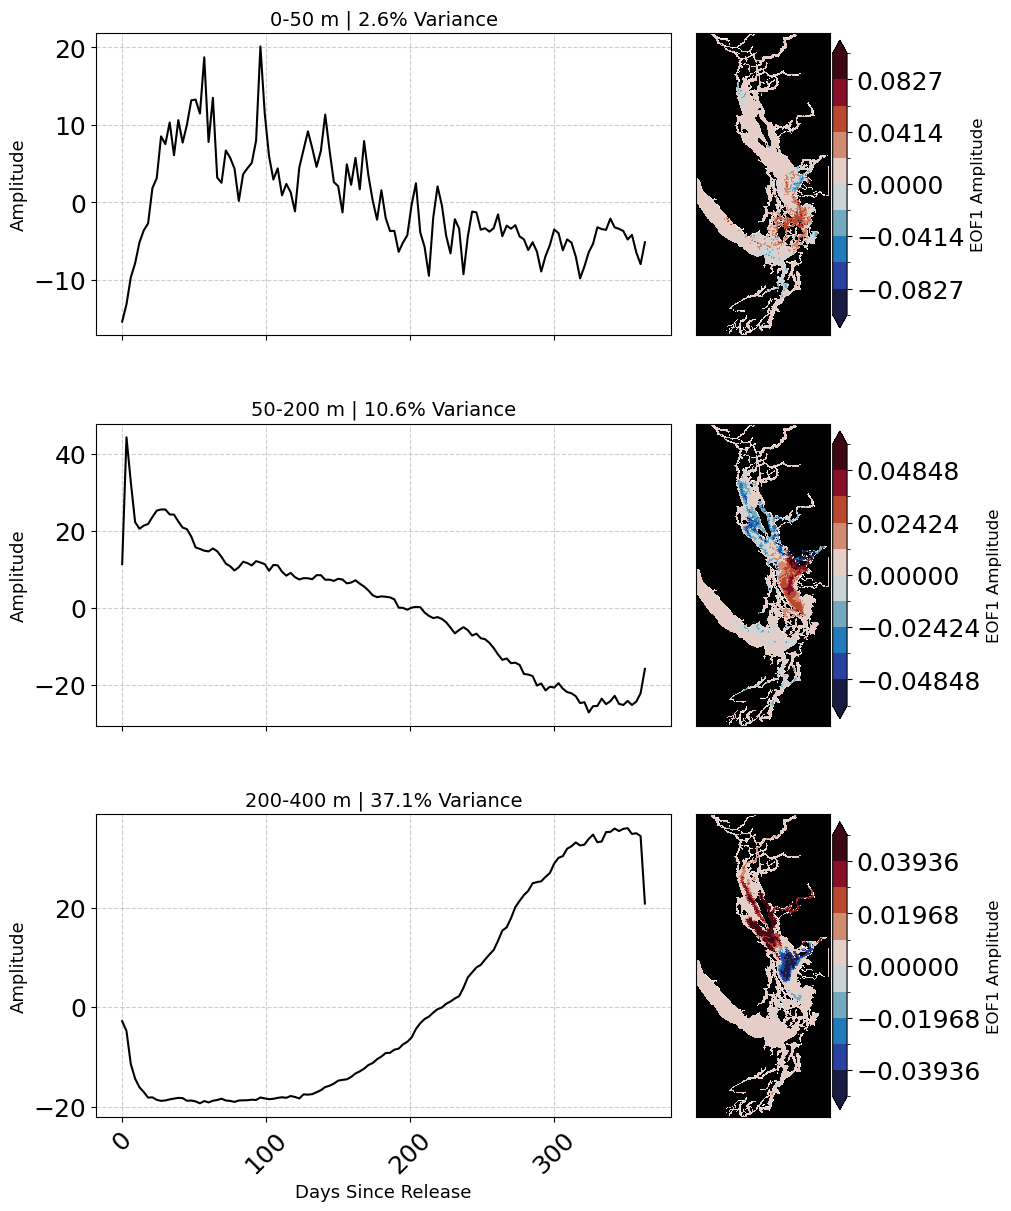

In [15]:
plot_seasonal_pca_on_grid('Fall', pca_results, mask)

# 4 seasons in one layer

In [24]:
from scipy.spatial import cKDTree

def particles_amount_map_aged(
    lons, lats, depths, ages, depth_bins, mask,
    num_lon=200, num_lat=200, age_freq_days=3, max_days=90 # Added max_days parameter
):
    # Floor ages to the nearest frequency bin (e.g., 0, 3, 6, 9 days)
    age_bins = (ages // age_freq_days) * age_freq_days
    
    # FIX: Dynamically stop the bins at the edge of your tracking window
    unique_ages = np.arange(0, max_days, age_freq_days) 

    # Create lon/lat bin edges and centers
    lon_edges = np.linspace(mask['nav_lon'].min(), mask['nav_lon'].max(), num_lon + 1)
    lat_edges = np.linspace(mask['nav_lat'].min(), mask['nav_lat'].max(), num_lat + 1)
    lon_centers = (lon_edges[:-1] + lon_edges[1:]) / 2
    lat_centers = (lat_edges[:-1] + lat_edges[1:]) / 2
    depth_labels = [f"{d0}-{d1} m" for d0, d1 in depth_bins]
    
    counts_out = np.zeros((len(unique_ages), len(depth_bins), num_lat, num_lon), dtype=int)
    
    # --- cKDTree Vectorized Grid Search ---
    Xedges, Yedges = np.meshgrid(lon_centers, lat_centers)
    mask_lon = mask.nav_lon.values.ravel()
    mask_lat = mask.nav_lat.values.ravel()
    tree = cKDTree(np.c_[mask_lon, mask_lat])
    target_pts = np.c_[Xedges.ravel(), Yedges.ravel()]
    _, nearest_indices = tree.query(target_pts)
    
    n_cols = mask.nav_lon.shape[1]
    jj_sed_master = (nearest_indices // n_cols).reshape(Xedges.shape)
    ii_sed_master = (nearest_indices % n_cols).reshape(Xedges.shape)
    ii_sed_out = {label: ii_sed_master for label in depth_labels}
    jj_sed_out = {label: jj_sed_master for label in depth_labels}
    
    # Fill histograms
    for d_idx, (d0, d1) in enumerate(depth_bins):
        depth_mask = (depths >= d0) & (depths < d1)
        if not np.any(depth_mask): continue

        lon_d = lons[depth_mask]
        lat_d = lats[depth_mask]
        age_d = age_bins[depth_mask]

        for t_idx, t in enumerate(unique_ages):
            t_mask = age_d == t
            if not np.any(t_mask): continue

            counts, _, _ = np.histogram2d(
                lon_d[t_mask], lat_d[t_mask],
                bins=[lon_edges, lat_edges]
            )
            counts_out[t_idx, d_idx, :, :] = counts.T.astype(int)

    # Wrap into xarray
    da = xr.DataArray(
        counts_out,
        coords={
            "time": unique_ages, 
            "depth_bin": depth_labels,
            "lat": lat_centers,
            "lon": lon_centers
        },
        dims=("time", "depth_bin", "lat", "lon"),
        name="particle_counts"
    )

    return da, ii_sed_out, jj_sed_out

In [25]:
# --- 1. CONFIGURATION ---
TRACKING_DAYS = 90
MAX_OBS = TRACKING_DAYS * 8  # 8 outputs per day = 720 steps

# Define your exact trajectory indices
idx_JFM = int((90 * 86400) / 900)    
idx_AMJ = int((181 * 86400) / 900)   
idx_JAS = int((273 * 86400) / 900)   
idx_OND = int((365 * 86400) / 900)   

seasons = {
    'Winter': slice(0, idx_JFM),
    'Spring': slice(idx_JFM, idx_AMJ),
    'Summer': slice(idx_AMJ, idx_JAS),
    'Fall': slice(idx_JAS, idx_OND)
}

depths_bins = [(0,50), (50,200), (200,400)]
depth_labels = [f"{d0}-{d1} m" for d0, d1 in depths_bins]

# --- 2. VECTORIZED 90-DAY AGE CALCULATION ---
print(f"Applying {TRACKING_DAYS}-day age mask to trajectory data...")

# [Make sure status_vals, lon_vals, lat_vals, depth_vals are loaded from DATA as before]
is_active = (status_vals > 0) & (status_vals < 4)
first_active_idx = np.argmax(is_active, axis=1) # The "birth" step of each particle

# Calculate the age (in obs steps) for every point in the matrix
obs_grid = np.arange(status_vals.shape[1]) 
age_obs = obs_grid[None, :] - first_active_idx[:, None] 

# Keep only points within 90 days of life AND active
valid_90d = (age_obs >= 0) & (age_obs < MAX_OBS) & is_active

# Filter matrices (invalid points become NaN)
lon_wat = np.where(valid_90d, lon_vals, np.nan)
lat_wat = np.where(valid_90d, lat_vals, np.nan)
depth_wat = np.where(valid_90d, depth_vals, np.nan)

# Convert valid age steps to Days
age_days_wat = np.where(valid_90d, age_obs / 8.0, np.nan)

# --- 3. AUTOMATED PCA PROCESSING ---
pca_results_90d = {}

for season_name, season_slice in seasons.items():
    print(f"Running PCA for {season_name} ({TRACKING_DAYS}-day footprint)...")
    
    # Flatten the data for the specific season and drop NaNs
    lon_s = lon_wat[season_slice, :].ravel()
    lat_s = lat_wat[season_slice, :].ravel()
    depth_s = depth_wat[season_slice, :].ravel()
    age_s = age_days_wat[season_slice, :].ravel()
    
    valid = ~np.isnan(lon_s)
    lon_s, lat_s, depth_s, age_s = lon_s[valid], lat_s[valid], depth_s[valid], age_s[valid]
    
    # Bin by age (0 to 90 days)
    da_season, ii_water, jj_water = particles_amount_map_aged(
            lons=lon_s, lats=lat_s, depths=depth_s, ages=age_s, 
            depth_bins=depths_bins, mask=mask, max_days=TRACKING_DAYS
        )
    
    pca_results_90d[season_name] = {
        'time': da_season.time.values, # This is now 0 to 90 Days
        'lon': da_season.lon.values,
        'lat': da_season.lat.values,
        'ii_map': ii_water,
        'jj_map': jj_water
    }
    
    for d_label in depth_labels:
        X_pca, pca_model, eigvecs, fracVar, X_std = run_pca(da_season, depth_bin=d_label)
        pca_results_90d[season_name][d_label] = {
            'X_pca': X_pca, 'model': pca_model, 'eigenvectors': eigvecs,
            'variance_ratio': fracVar, 'standardized_data': X_std
        }

print("90-Day Seasonal PCA processing complete!")

Applying 90-day age mask to trajectory data...
Running PCA for Winter (90-day footprint)...
Running PCA for Spring (90-day footprint)...
Running PCA for Summer (90-day footprint)...
Running PCA for Fall (90-day footprint)...
90-Day Seasonal PCA processing complete!


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cm
from matplotlib.colors import ListedColormap

# Define the custom colormap for the visual land mask overlay
colors = [(0.5, 0.5, 0.5, 1),   # Grey for land (0 in tmask)
          (0, 0, 0, 0)]         # Transparent for water (1 in tmask)
cmap_land = ListedColormap(colors)

def plot_layer_pca_on_grid(depth_label, pca_results, mask):
    """
    Plots a 4-row by 2-column figure for a specific depth layer.
    Left column: PC1 Time Series (Days Since Release). Right column: PC1 Spatial Map.
    """
    seasons = ['Winter', 'Spring', 'Summer', 'Fall']
    
    # Extract centers from the first season (they are identical across seasons)
    lon_centers = pca_results['Winter']['lon']
    lat_centers = pca_results['Winter']['lat']
    
    # ---------------------------------------------------------
    # GRID MAPPING SETUP
    # ---------------------------------------------------------
    nav_lon = mask['nav_lon'].values.squeeze()
    nav_lat = mask['nav_lat'].values.squeeze()
    tmask = mask['tmask'][0][0].values
    
    lon_edges = np.linspace(mask['nav_lon'].min().item(), mask['nav_lon'].max().item(), len(lon_centers) + 1)
    lat_edges = np.linspace(mask['nav_lat'].min().item(), mask['nav_lat'].max().item(), len(lat_centers) + 1)
    
    bin_x = np.digitize(nav_lon, lon_edges) - 1
    bin_x = np.clip(bin_x, 0, len(lon_centers) - 1)
    
    bin_y = np.digitize(nav_lat, lat_edges) - 1
    bin_y = np.clip(bin_y, 0, len(lat_centers) - 1)
    
    x = np.arange(0, 398) # X-dimension
    y = np.arange(0, 898) # Y-dimension

    # ---------------------------------------------------------
    # LAYOUT SETUP (4 Rows now, taller figsize)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(
            nrows=4, ncols=2, figsize=(10, 16), sharex='col',
            layout='constrained',  
            gridspec_kw={'width_ratios': [2, 0.5], 'wspace': 0.03, 'hspace': 0.15}
        )

    # Setup discrete diverging colormap
    base_cmap = cm.balance
    n_discrete_levels = 11  
    discrete_cmap = plt.get_cmap(base_cmap, n_discrete_levels - 1)

    for i, season in enumerate(seasons):
        ax_time = axes[i, 0]
        ax_map = axes[i, 1]
        
        # Extract data for this specific season and requested layer
        time_array = pca_results[season]['time']
        pca_data = pca_results[season][depth_label]
        X_pca = pca_data['X_pca']               
        eigvecs = pca_data['eigenvectors']
        fracVar = pca_data['variance_ratio']
        
        # Format the variance for the first component (PC1) as a percentage
        pc1_var = fracVar[1] * 100 
        
        # ---------------------------------------------------------
        # LEFT COLUMN: PC1 Time Series
        # ---------------------------------------------------------
        pc1_timeseries = X_pca[:, 1]
        
        ax_time.plot(time_array, pc1_timeseries, color='black', linewidth=1.5)
        ax_time.set_title(f'{season.upper()} ({depth_label}) | {pc1_var:.1f}% Variance', fontsize=16, fontweight='bold')
        ax_time.set_ylabel('Amplitude', fontsize=14)
        ax_time.grid(True, linestyle='--', alpha=0.6)
        
        # X-axis label handling (Now on the 4th row, index 3)
        if i == 3:
            ax_time.set_xlabel('Days Since Release', fontsize=14)
            
        # ---------------------------------------------------------
        # RIGHT COLUMN: PC1 Spatial Map (Projected to Model Grid)
        # ---------------------------------------------------------
        eof1 = eigvecs[1, :]
        eof1_2d = eof1.reshape(len(lat_centers), len(lon_centers))
        
        model_grid_eof = eof1_2d[bin_y, bin_x]
        model_grid_eof = np.where(tmask == 1, model_grid_eof, np.nan)
        
        vmax = np.nanmax(np.abs(model_grid_eof))
        vmin = -vmax
        levels = np.linspace(vmin, vmax, n_discrete_levels)
        norm = mcolors.BoundaryNorm(levels, ncolors=discrete_cmap.N, clip=True)
        
        mesh = ax_map.pcolormesh(
            x, y, model_grid_eof, 
            cmap=discrete_cmap, 
            norm=norm, 
            shading='auto'
        )
        
        # Add the grey land mask overlay
        ax_map.pcolormesh(mask['tmask'][0][0], cmap=cmap_land, zorder=2)
        
        # Lock the aspect ratio so the physical map dimensions stay true
        ax_map.set_aspect('equal', 'box')
        
        ax_map.set_xticks([])
        ax_map.set_yticks([])        
            
        cbar = fig.colorbar(mesh, ax=ax_map, extend='both', pad=0.02, fraction=0.1)
        cbar.set_label('EOF2 Amplitude', fontsize=12)

    plt.show()


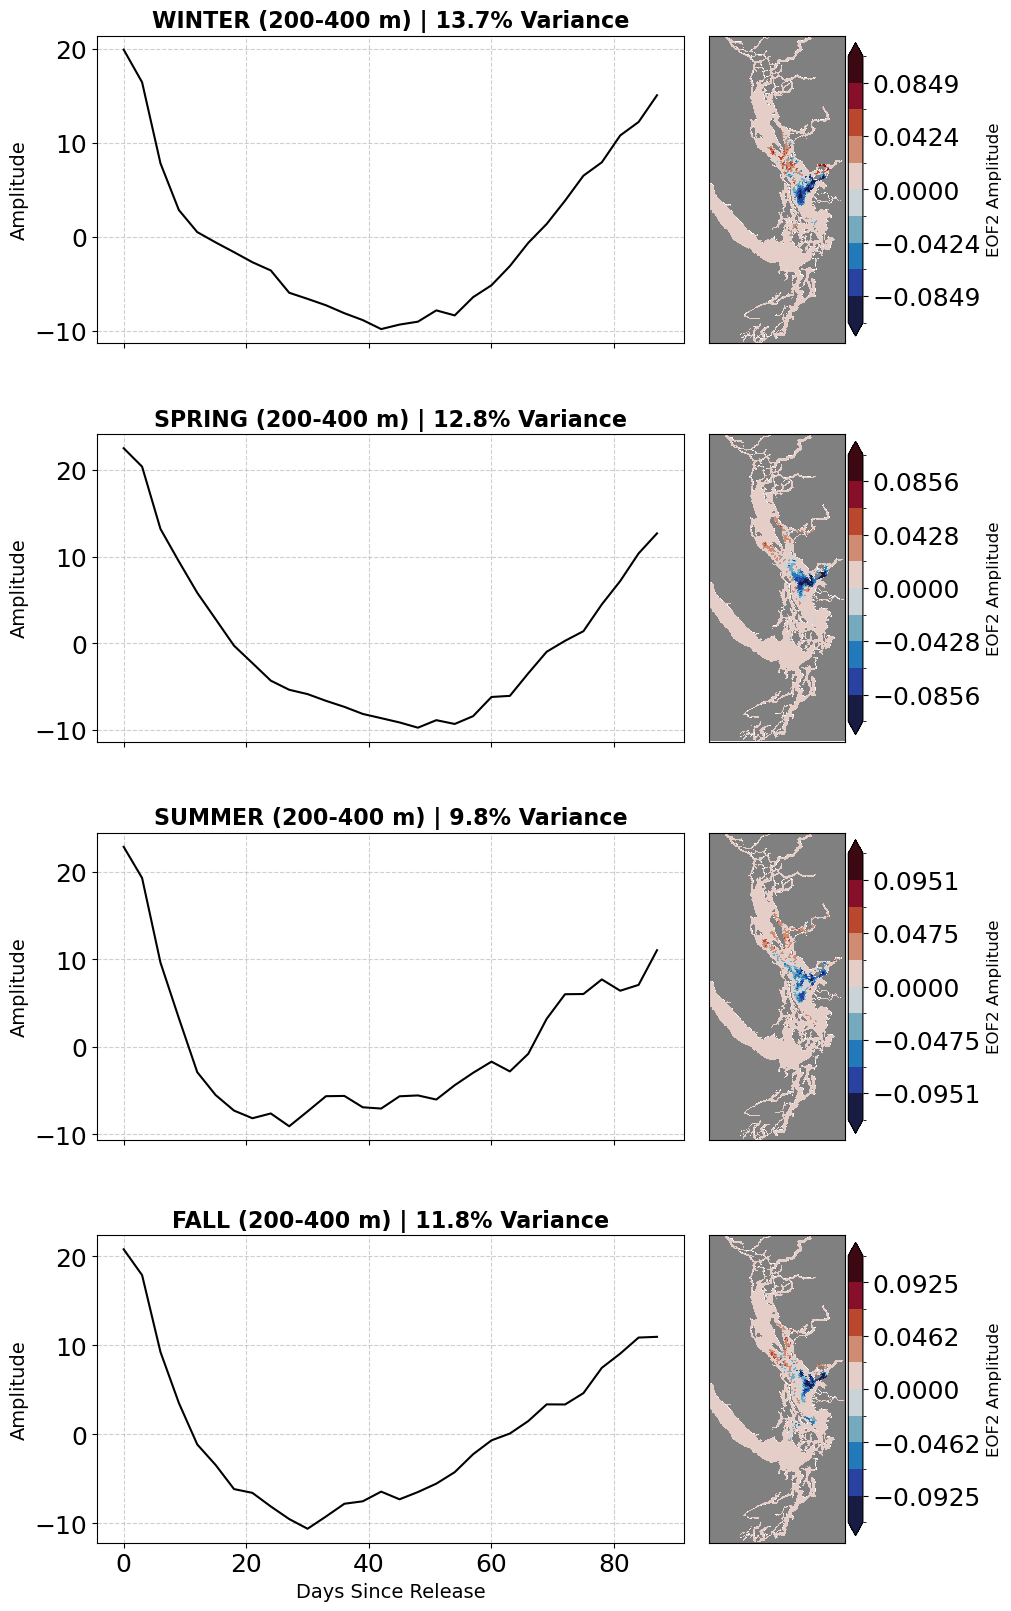

In [37]:
plot_layer_pca_on_grid('200-400 m', pca_results_90d, mask)

In [38]:
# plot_layer_pca_on_grid('50-200 m', pca_results, mask)
# plot_layer_pca_on_grid('200-400 m', pca_results, mask)